In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal as _lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

%cd {PROJECT_ROOT}

PROJECT_ROOT: /home/victor/gw/cbc_pe
cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']
/home/victor/gw/cbc_pe


### Debug 500 samples

In [ ]:
from src.io import load_dataset_npz

loaded = load_dataset_npz("data/debug/bbh_debug_500.npz")

In [ ]:
X = loaded.X
y = loaded.y
metadata = loaded.metadata
parameters = loaded.parameters

print(loaded.X.shape)
print(loaded.y.shape)
print(len(loaded.parameters))
print(len(loaded.metadata))


In [ ]:

snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])
initial_snrs = np.array([m["snr"]["initial_network_snr"] for m in metadata])
rescaled = np.array([m["snr"]["snr_rescaled"] for m in metadata])
truncated = np.array([m["windowing"]["is_truncated"] for m in metadata])

clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in metadata
])

margins = np.array([
    m["placement"].get("margins_respected", False)
    for m in metadata
])

m1 = np.array([p["mass_1"] for p in parameters])
m2 = np.array([p["mass_2"] for p in parameters])
distance = np.array([p["distance"] for p in parameters])
chirp = np.array([p["chirp_mass"] for p in parameters])
mtot = np.array([p["total_mass"] for p in parameters])
chieff = np.array([p["chi_eff"] for p in parameters])

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

print("\nSNR")
print("final min/mean/max:", snrs.min(), snrs.mean(), snrs.max())
print("initial min/mean/max:", initial_snrs.min(), initial_snrs.mean(), initial_snrs.max())
print("rescaled:", rescaled.sum(), "/", len(rescaled))

print("\nWindow / injection")
print("truncated:", truncated.sum(), "/", len(truncated))
print("clipped:", clipped.sum(), "/", len(clipped))
print("margins respected:", margins.sum(), "/", len(margins))

print("\nParameters")
print("m1 min/mean/max:", m1.min(), m1.mean(), m1.max())
print("m2 min/mean/max:", m2.min(), m2.mean(), m2.max())
print("distance min/mean/max:", distance.min(), distance.mean(), distance.max())
print("chirp min/mean/max:", chirp.min(), chirp.mean(), chirp.max())
print("mtot min/mean/max:", mtot.min(), mtot.mean(), mtot.max())
print("chieff min/mean/max:", chieff.min(), chieff.mean(), chieff.max())

In [ ]:
low, high = 10.0, 25.0
tol = loaded.metadata[0]["simulation"]["snr_relative_tolerance"]

assert np.all(snrs >= low * (1 - tol))
assert np.all(snrs <= high * (1 + tol))
assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)
assert np.all((-1 <= chieff) & (chieff <= 1))
assert not np.any(clipped)
assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("Loaded 500 dataset checks OK")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(snrs, bins=30)
plt.axvline(10, linestyle="--")
plt.axvline(25, linestyle="--")
plt.xlabel("Final network SNR")
plt.ylabel("Count")
plt.title("Final network SNR")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(m1, bins=30, alpha=0.6, label="m1")
plt.hist(m2, bins=30, alpha=0.6, label="m2")
plt.xlabel("Component mass [Msun]")
plt.ylabel("Count")
plt.title("Component mass distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(distance, bins=30)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Count")
plt.title("Final distance after possible SNR rescaling")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(mtot, snrs, s=10)
plt.xlabel("Total mass [Msun]")
plt.ylabel("Final network SNR")
plt.title("SNR vs total mass")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(distance, snrs, s=10)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Final network SNR")
plt.title("SNR vs distance")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(mtot, truncated.astype(int), s=10)
plt.xlabel("Total mass [Msun]")
plt.ylabel("Is truncated")
plt.title("Truncation vs total mass")
plt.grid(alpha=0.3)
plt.show()

In [10]:
def plot_loaded_sample(loaded, i, config_length=None):
    X = loaded.X[i]
    meta = loaded.metadata[i]
    params = loaded.parameters[i]

    fs = meta["simulation"]["sampling_frequency"]
    dt = 1.0 / fs
    t = np.arange(X.shape[1]) * dt

    detectors = meta["detectors"]

    fig, axes = plt.subplots(len(detectors), 1, figsize=(12, 6), sharex=True)
    if len(detectors) == 1:
        axes = [axes]

    for j, det in enumerate(detectors):
        axes[j].plot(t, X[j])
        axes[j].set_ylabel(det)
        axes[j].grid(alpha=0.3)

    axes[-1].set_xlabel("Time from segment start [s]")

    fig.suptitle(
        f"Sample {i} | SNR={meta['snr']['final_network_snr']:.2f} | "
        f"m1={params['mass_1']:.1f}, m2={params['mass_2']:.1f}, "
        f"truncated={meta['windowing']['is_truncated']}"
    )

    plt.tight_layout()
    plt.show()

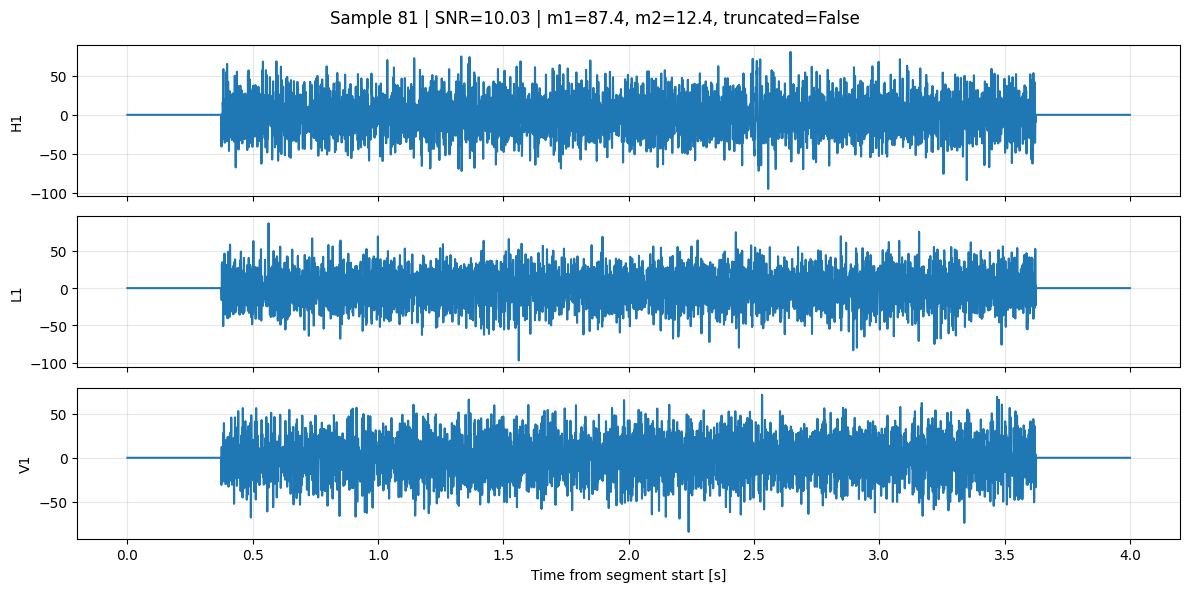

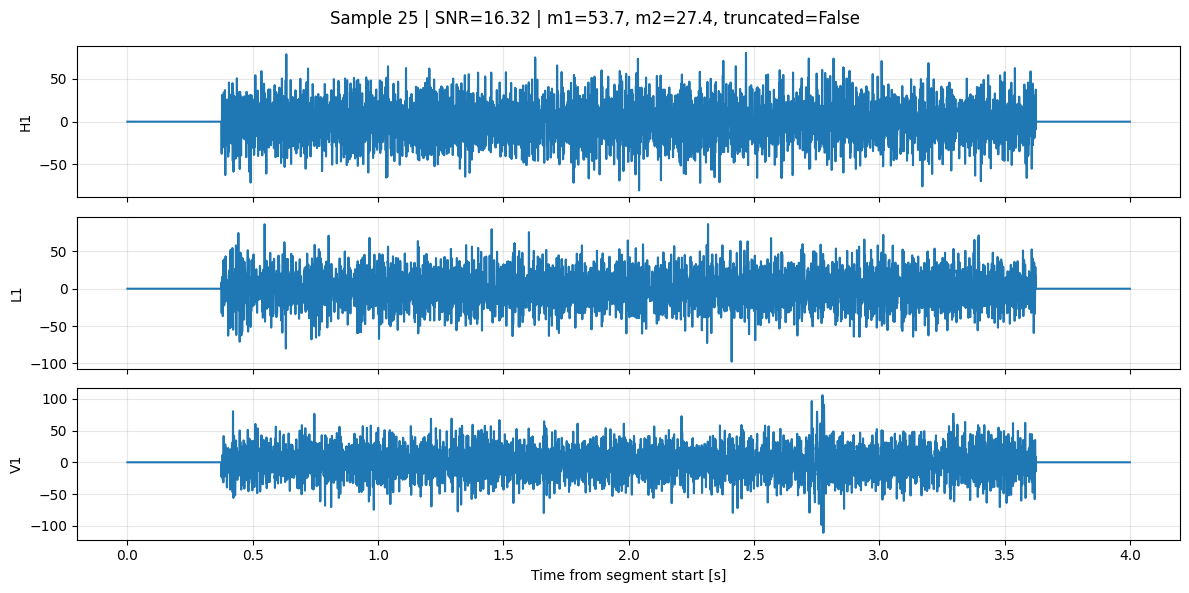

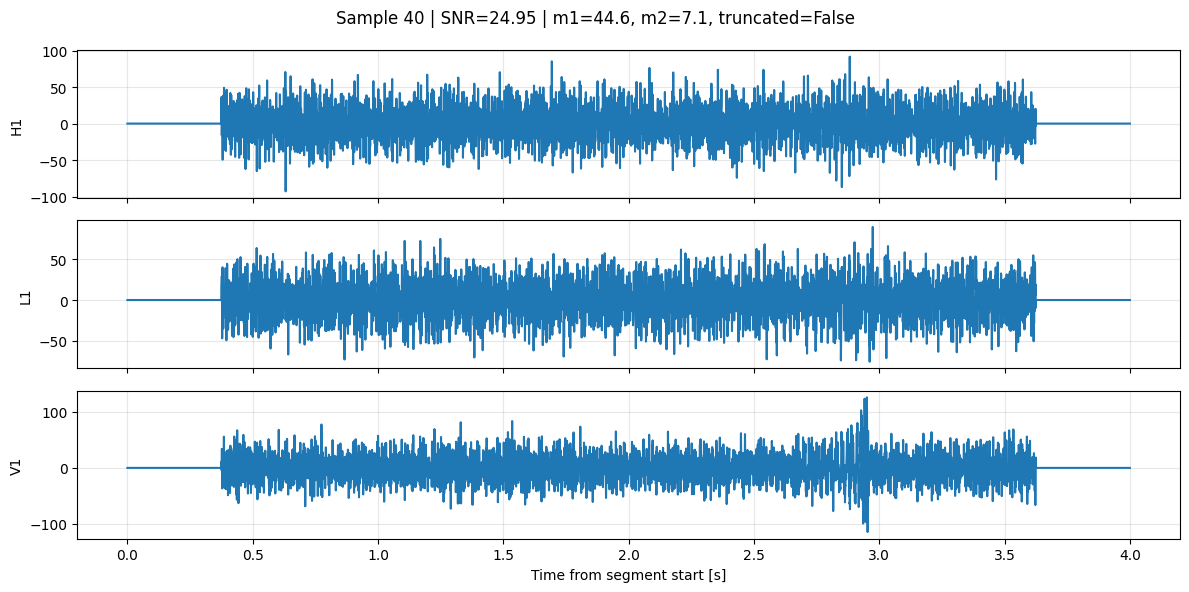

In [11]:
idx_sorted_snr = np.argsort(snrs)

for i in [idx_sorted_snr[0], idx_sorted_snr[len(idx_sorted_snr)//2], idx_sorted_snr[-1]]:
    plot_loaded_sample(loaded, i)

In [17]:
truncated_indices = np.where(truncated)[0]

for i in truncated_indices[:3]:
    plot_loaded_sample(loaded, i)

### 4500 debugging

In [24]:
from src.io import load_dataset_npz
import numpy as np

loaded = load_dataset_npz("data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n4500.npz")

X = loaded.X
y = loaded.y
parameters = loaded.parameters
metadata = loaded.metadata

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("parameters:", len(parameters))
print("metadata:", len(metadata))

X: (4500, 3, 16384) float32
y: (4500, 3) float32
parameters: 4500
metadata: 4500


In [25]:
assert X.shape == (4500, 3, 16384)
assert y.shape == (4500, 3)
assert len(parameters) == 4500
assert len(metadata) == 4500
assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("Basic loaded checks OK")

Basic loaded checks OK


In [26]:
snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])
initial_snrs = np.array([m["snr"]["initial_network_snr"] for m in metadata])
rescaled = np.array([m["snr"]["snr_rescaled"] for m in metadata])
truncated = np.array([m["windowing"]["is_truncated"] for m in metadata])

clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in metadata
])

margins = np.array([
    m["placement"].get("margins_respected", False)
    for m in metadata
])

m1 = np.array([p["mass_1"] for p in parameters])
m2 = np.array([p["mass_2"] for p in parameters])
distance = np.array([p["distance"] for p in parameters])
chirp = np.array([p["chirp_mass"] for p in parameters])
mtot = np.array([p["total_mass"] for p in parameters])
chieff = np.array([p["chi_eff"] for p in parameters])

print("SNR final min/mean/max:", snrs.min(), snrs.mean(), snrs.max())
print("SNR initial min/mean/max:", initial_snrs.min(), initial_snrs.mean(), initial_snrs.max())
print("Rescaled:", rescaled.sum(), "/", len(rescaled))
print("Truncated:", truncated.sum(), "/", len(truncated))
print("Clipped:", clipped.sum(), "/", len(clipped))
print("Margins respected:", margins.sum(), "/", len(margins))

print("m1 min/mean/max:", m1.min(), m1.mean(), m1.max())
print("m2 min/mean/max:", m2.min(), m2.mean(), m2.max())
print("distance min/mean/max:", distance.min(), distance.mean(), distance.max())
print("chirp min/mean/max:", chirp.min(), chirp.mean(), chirp.max())
print("mtot min/mean/max:", mtot.min(), mtot.mean(), mtot.max())
print("chi_eff min/mean/max:", chieff.min(), chieff.mean(), chieff.max())

SNR final min/mean/max: 10.001353331354656 16.945084847412996 24.999983799633906
SNR initial min/mean/max: 0.4652389137791541 17.68650048864028 263.35019401880686
Rescaled: 3129 / 4500
Truncated: 0 / 4500
Clipped: 0 / 4500
Margins respected: 4500 / 4500
m1 min/mean/max: 8.52469158770893 62.202430062226256 89.99974875040378
m2 min/mean/max: 5.010646374888234 33.7370712130234 87.8356211986566
distance min/mean/max: 47.74183626153526 1698.3649837218263 8370.233322725631
chirp min/mean/max: 6.511436705951678 37.790642548635184 76.80175565901058
mtot min/mean/max: 16.401795671750993 95.93950127524965 176.4461426629411
chi_eff min/mean/max: -0.9897989843134043 -0.002181528788395018 0.9781015493195233


In [27]:
tol = metadata[0]["simulation"]["snr_relative_tolerance"]
low, high = metadata[0]["simulation"]["target_network_snr_range"]

assert np.all(snrs >= low * (1 - tol))
assert np.all(snrs <= high * (1 + tol))
assert not np.any(clipped)
assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)
assert np.all((-1.0 <= chieff) & (chieff <= 1.0))

print("Physics/SNR loaded checks OK")

Physics/SNR loaded checks OK


train: 2000
val:    500
cal:    500
test:   500

In [31]:
from pathlib import Path
import numpy as np

N = X.shape[0]
assert N == 4500

split_rng = np.random.default_rng(2026)
indices = split_rng.permutation(N)

n_train = 3000
n_val = 500
n_cal = 500
n_test = 500

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
cal_idx = indices[n_train + n_val:n_train + n_val + n_cal]
test_idx = indices[n_train + n_val + n_cal:]

assert len(train_idx) == n_train
assert len(val_idx) == n_val
assert len(cal_idx) == n_cal
assert len(test_idx) == n_test

split_path = Path("data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_splits.npz")

np.savez(
    split_path,
    train_idx=train_idx,
    val_idx=val_idx,
    cal_idx=cal_idx,
    test_idx=test_idx,
)

print("Saved splits to:", split_path)

Saved splits to: data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_splits.npz


In [29]:
y_train = y[train_idx]

label_mean = y_train.mean(axis=0)
label_std = y_train.std(axis=0)

print("label_mean:", label_mean)
print("label_std:", label_std)

assert np.all(label_std > 0)

stats_path = Path("data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n4500_label_stats.npz")

np.savez(
    stats_path,
    label_mean=label_mean,
    label_std=label_std,
    label_names=np.array(["chirp_mass", "total_mass", "chi_eff"]),
)

print("Saved label stats to:", stats_path)

label_mean: [ 3.7720432e+01  9.5792854e+01 -3.6983883e-03]
label_std: [16.760782   34.854946    0.43916413]
Saved label stats to: data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n4500_label_stats.npz


In [30]:
y_train_std = (y[train_idx] - label_mean) / label_std
y_val_std = (y[val_idx] - label_mean) / label_std
y_cal_std = (y[cal_idx] - label_mean) / label_std
y_test_std = (y[test_idx] - label_mean) / label_std

print(y_train_std.mean(axis=0))
print(y_train_std.std(axis=0))

[ 2.8971433e-06 -1.0763009e-06  9.8148982e-09]
[1.0000001  0.99999976 1.0000002 ]


### 100 debug

In [8]:
from src.io import load_dataset_npz
import numpy as np

loaded = load_dataset_npz("data/processed/bbh_raw_4s_seobnrv4opt_snr10-25_n100.npz")

X = loaded.X
y = loaded.y
parameters = loaded.parameters
metadata = loaded.metadata

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("parameters:", len(parameters))
print("metadata:", len(metadata))

X: (100, 3, 16384) float32
y: (100, 3) float32
parameters: 100
metadata: 100


In [9]:
snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])
initial_snrs = np.array([m["snr"]["initial_network_snr"] for m in metadata])
rescaled = np.array([m["snr"]["snr_rescaled"] for m in metadata])
truncated = np.array([m["windowing"]["is_truncated"] for m in metadata])

clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in metadata
])

margins = np.array([
    m["placement"].get("margins_respected", False)
    for m in metadata
])

m1 = np.array([p["mass_1"] for p in parameters])
m2 = np.array([p["mass_2"] for p in parameters])
distance = np.array([p["distance"] for p in parameters])
chirp = np.array([p["chirp_mass"] for p in parameters])
mtot = np.array([p["total_mass"] for p in parameters])
chieff = np.array([p["chi_eff"] for p in parameters])

print("SNR final min/mean/max:", snrs.min(), snrs.mean(), snrs.max())
print("SNR initial min/mean/max:", initial_snrs.min(), initial_snrs.mean(), initial_snrs.max())
print("Rescaled:", rescaled.sum(), "/", len(rescaled))
print("Truncated:", truncated.sum(), "/", len(truncated))
print("Clipped:", clipped.sum(), "/", len(clipped))
print("Margins respected:", margins.sum(), "/", len(margins))

print("m1 min/mean/max:", m1.min(), m1.mean(), m1.max())
print("m2 min/mean/max:", m2.min(), m2.mean(), m2.max())
print("distance min/mean/max:", distance.min(), distance.mean(), distance.max())
print("chirp min/mean/max:", chirp.min(), chirp.mean(), chirp.max())
print("mtot min/mean/max:", mtot.min(), mtot.mean(), mtot.max())
print("chi_eff min/mean/max:", chieff.min(), chieff.mean(), chieff.max())

SNR final min/mean/max: 10.026111138170595 16.686426882944726 24.94901491430704
SNR initial min/mean/max: 0.8252853086691044 18.804822109937792 127.34384135088884
Rescaled: 75 / 100
Truncated: 0 / 100
Clipped: 0 / 100
Margins respected: 100 / 100
m1 min/mean/max: 16.241034888618678 63.00624205677287 89.92648828178483
m2 min/mean/max: 5.472494185803389 31.253853132796124 79.69385507769496
distance min/mean/max: 236.68990072288253 1859.6995932889608 8283.464745488103
chirp min/mean/max: 9.185721018241589 36.406893692067435 71.80807359944923
mtot min/mean/max: 23.667954531592105 94.260095189569 165.08982923135807
chi_eff min/mean/max: -0.8846065332990243 0.07941080943174209 0.9096462858215006


In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

dataset_id = "bbh_psdwhite_context4p8125_crop4s_seobnrv4opt_snr10-25_n100"

dataset_path = Path("data/processed") / f"{dataset_id}.npz"
metadata_path = Path("data/processed") / f"{dataset_id}.metadata.json"

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

X: (100, 3, 16384) float32
y: (100, 3) float32


In [13]:
zero_fraction_global = np.mean(X == 0.0)
zero_fraction_by_detector = np.mean(X == 0.0, axis=(0, 2))

print("zero_fraction_global:", zero_fraction_global)

for det, zf in zip(metadata[0]["detectors"], zero_fraction_by_detector):
    print(det, zf)

zero_fraction_global: 0.0
H1 0.0
L1 0.0
V1 0.0


In [14]:
zero_by_time = np.mean(X == 0.0, axis=(0, 1))

print("zero_by_time first 20:", zero_by_time[:20])
print("zero_by_time last 20:", zero_by_time[-20:])
print("zero_by_time max:", zero_by_time.max())

zero_by_time first 20: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
zero_by_time last 20: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
zero_by_time max: 0.0


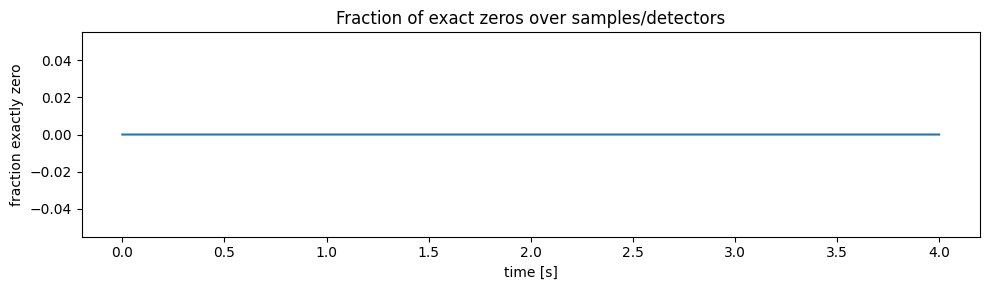

In [15]:
time = np.arange(X.shape[-1]) / 4096.0

plt.figure(figsize=(10, 3))
plt.plot(time, zero_by_time)
plt.xlabel("time [s]")
plt.ylabel("fraction exactly zero")
plt.title("Fraction of exact zeros over samples/detectors")
plt.tight_layout()
plt.show()

In [16]:
for i, m in enumerate(metadata):
    ctx = m["processing_context"]
    placement = m["placement"]

    assert abs(ctx["output_segment_start_time"] - placement["segment_start_time"]) < 1e-9
    assert abs(ctx["output_segment_end_time"] - placement["segment_end_time"]) < 1e-9

    for det in m["detectors"]:
        inj = m["injection"][det]

        assert abs(inj["segment_start_time"] - ctx["context_segment_start_time"]) < 1e-6
        assert abs(inj["segment_end_time"] - ctx["context_segment_end_time"]) < 1e-6

        assert inj["is_partially_clipped"] is False
        assert inj["n_signal_samples"] == inj["n_injected_samples"]

print("Temporal context/injection checks passed.")

Temporal context/injection checks passed.


In [17]:
for i, m in enumerate(metadata):
    assert m["processing_context"]["output_length"] == 16384
    assert abs(m["processing_context"]["output_duration"] - 4.0) < 1e-12
    assert m["processing_context"]["processing_input_length"] > 16384
    assert m["processing_context"]["context_start_samples"] == 1664
    assert m["processing_context"]["context_end_samples"] == 1664

print("Processing context metadata checks passed.")

Processing context metadata checks passed.


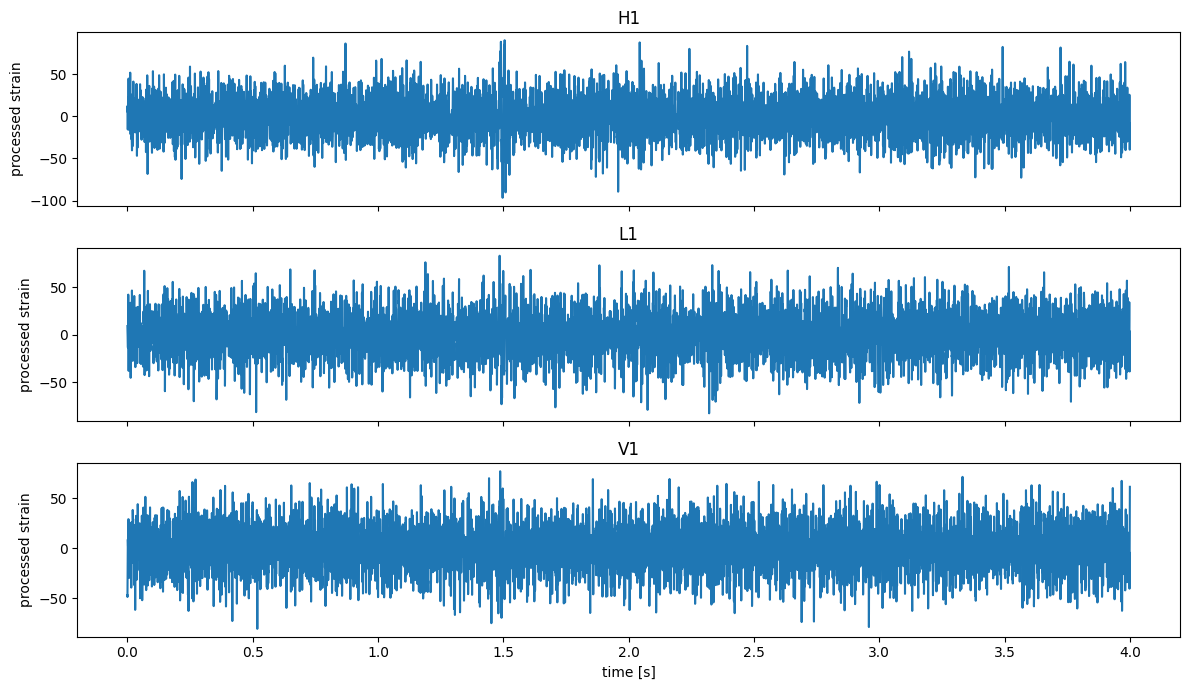

In [ ]:
sample_idx = 0
detectors = metadata[sample_idx]["detectors"]
fs = 4096.0
time = np.arange(X.shape[-1]) / fs

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for c, det in enumerate(detectors):
    axes[c].plot(time, X[sample_idx, c])
    axes[c].set_title(det)
    axes[c].set_ylabel("processed strain")

axes[-1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [19]:
m = metadata[sample_idx]
ctx = m["processing_context"]

output_start = ctx["output_segment_start_time"]

for det in detectors:
    inj = m["injection"][det]

    signal_start_rel = inj["signal_start_time"] - output_start
    signal_end_rel = inj["signal_end_time"] - output_start

    print(det, signal_start_rel, signal_end_rel)

H1 1.4502062797546387 1.7470812797546387
L1 1.4411730766296387 1.7380480766296387
V1 1.4411730766296387 1.7378039360046387


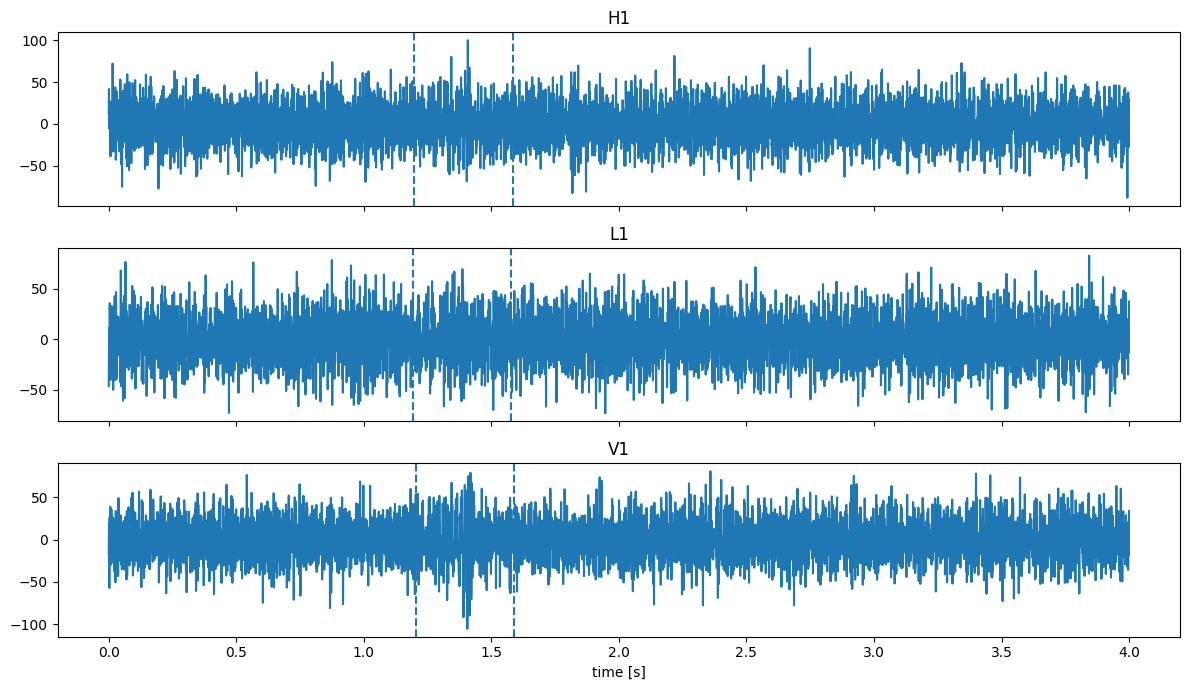

In [22]:
sample_idx = 10
m = metadata[sample_idx]
detectors = m["detectors"]
ctx = m["processing_context"]
output_start = ctx["output_segment_start_time"]

time = np.arange(X.shape[-1]) / 4096.0

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for c, det in enumerate(detectors):
    axes[c].plot(time, X[sample_idx, c])
    
    inj = m["injection"][det]
    signal_start_rel = inj["signal_start_time"] - output_start
    signal_end_rel = inj["signal_end_time"] - output_start

    axes[c].axvline(signal_start_rel, linestyle="--")
    axes[c].axvline(signal_end_rel, linestyle="--")
    axes[c].set_title(det)

axes[-1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

In [23]:
snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])

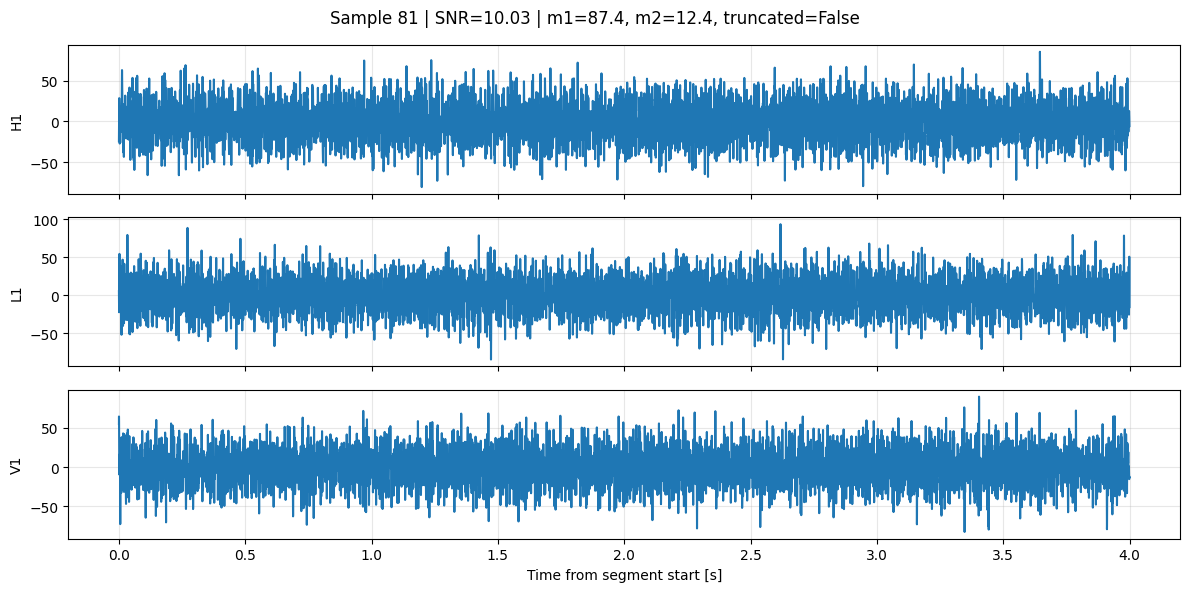

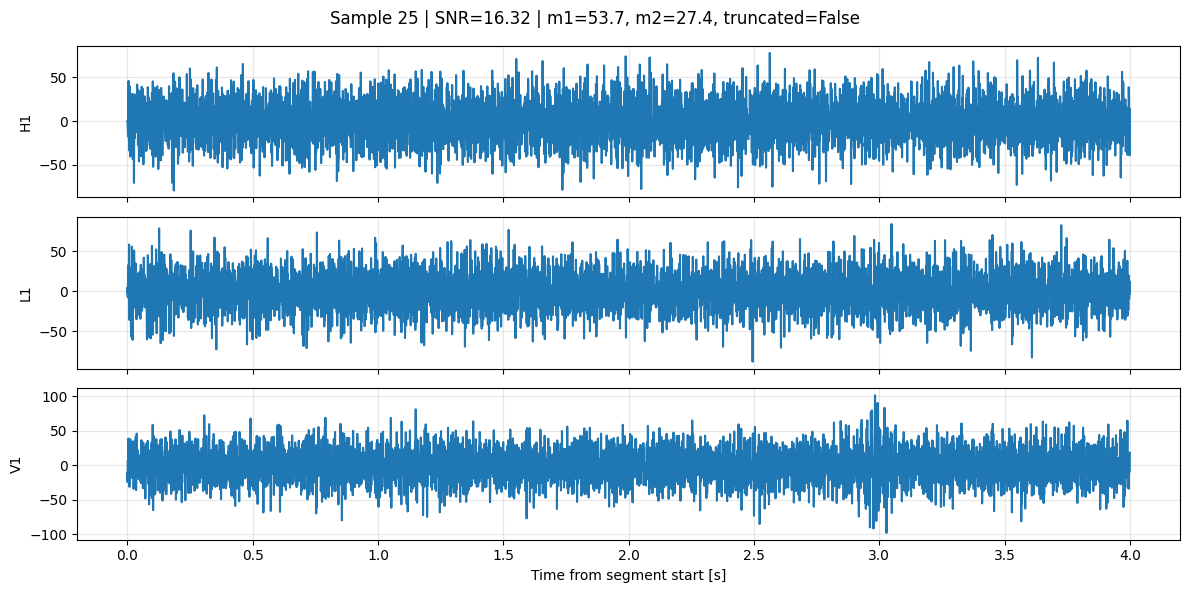

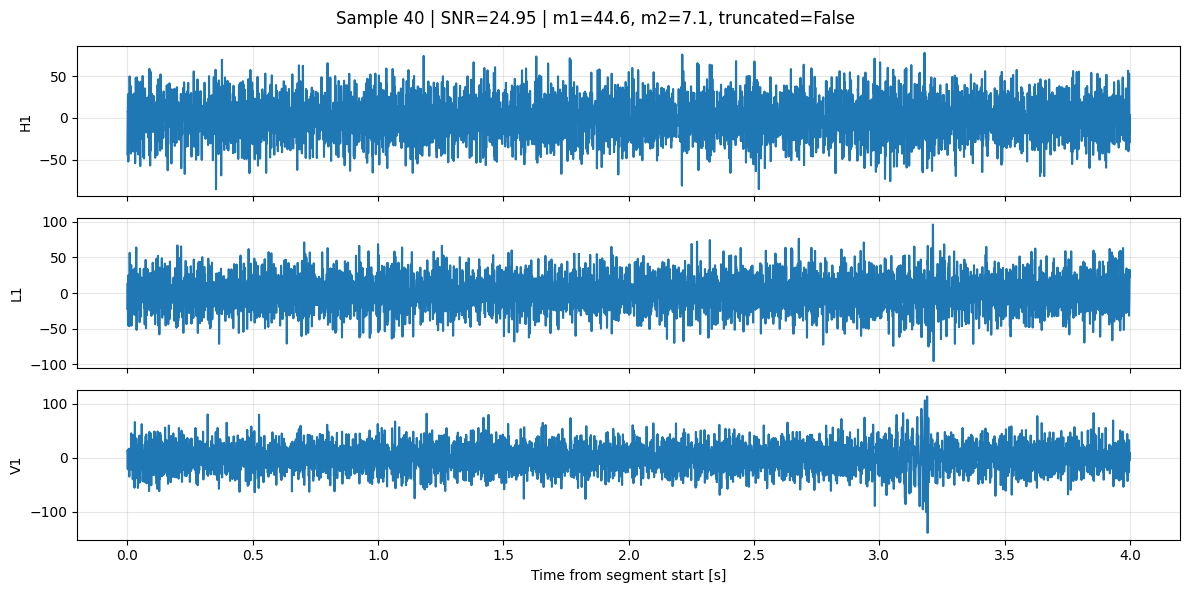

In [25]:
idx_sorted_snr = np.argsort(snrs)

for i in [idx_sorted_snr[0], idx_sorted_snr[len(idx_sorted_snr)//2], idx_sorted_snr[-1]]:
    plot_loaded_sample(batch, i)